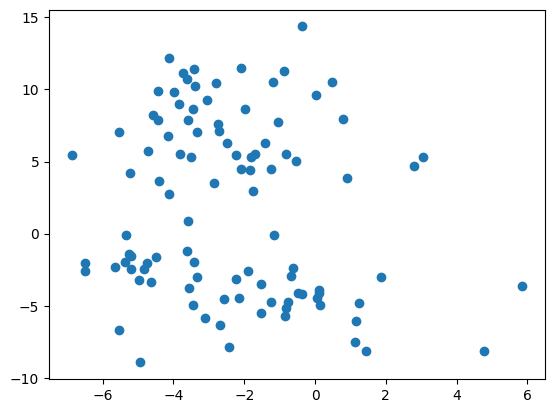

In [14]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=100, n_features=2, centers=4,
                  cluster_std=1.8,random_state=50)

plt.scatter(X[:,0], X[:,1])

## WCSS and the Elbow Method

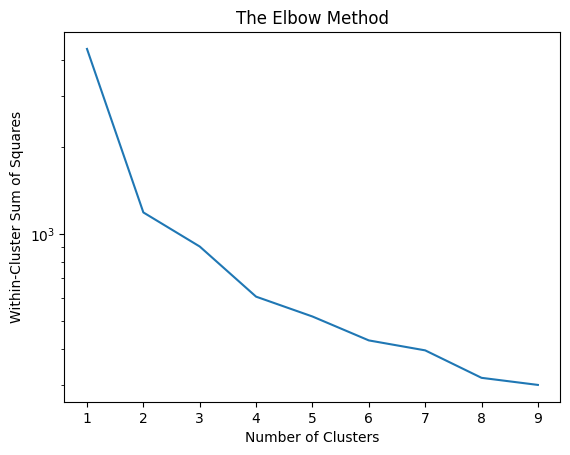

In [3]:
from sklearn.cluster import KMeans

num_clusters = []
wcss = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X)
    num_clusters.append(k)
    wcss.append(kmeans.inertia_)

plt.plot(num_clusters,wcss)
plt.yscale('log') # sets y-axis to a logarithmic scale to emphasize change in slope
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Within-Cluster Sum of Squares')
plt.show()

## Evaluate without labels

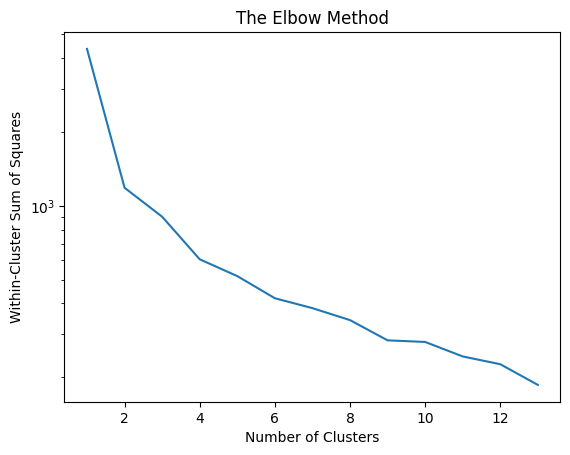

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

X, y = make_blobs(n_samples=100, n_features=2, centers=4,
                  cluster_std=1.8,random_state=50)


# Evaluate using WCSS and Elbow Method
num_clusters = []
wcss = []

for k in range(1, 14):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X)
    num_clusters.append(k)
    wcss.append(kmeans.inertia_)

plt.plot(num_clusters,wcss)
plt.yscale('log')
plt.title('The Elbow Method') # sets y-axis to a logarithmic scale to emphasize change in slope
plt.xlabel('Number of Clusters')
plt.ylabel('Within-Cluster Sum of Squares')
plt.show()

## Number-guessing game

In [ ]:
rnd_num = np.random.randint(2,10)

In [ ]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=100, n_features=2, centers=rnd_num,
                  cluster_std=0.7, random_state=99)

num_clusters = []
wcss = []

for k in range(1,14):
  kmeans = KMeans(n_clusters=k)
  kmeans.fit(X)
  num_clusters.append(k)
  wcss.append(kmeans.inertia_)

plt.plot(num_clusters, wcss)
plt.yscale('log')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Within-Cluster Sum of Squares')
plt.show()

In [ ]:
print(rnd_num)

## Silhouette Scores

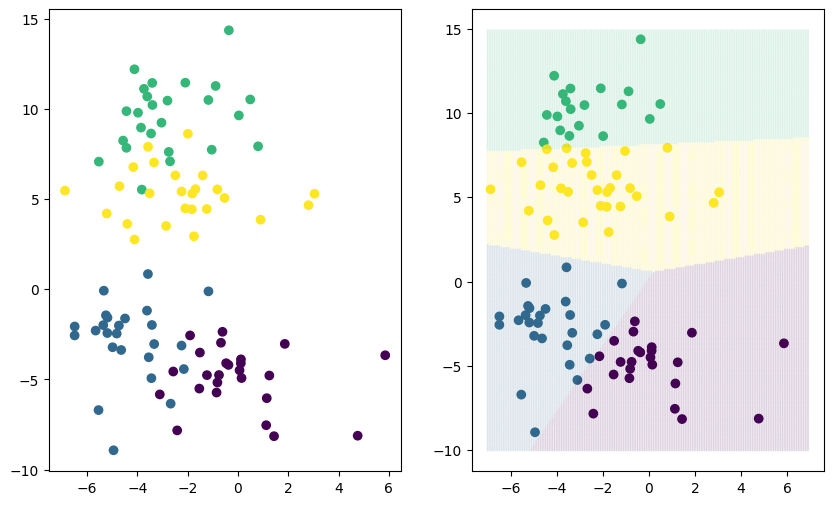

In [15]:
from sklearn.cluster import KMeans

k=4
kmeans = KMeans(n_clusters=k, random_state=30, n_init='auto')
kmeans.fit(X)

relabel = np.choose(kmeans.labels_,[0,3,1,2])
#y_pred = np.choose(y_test)

# Results Map
grid_x, grid_y = np.meshgrid(np.arange(-7, 7, 0.1), np.arange(-10, 15, 0.1))
grid_pts = np.array([grid_x.flatten(),grid_y.flatten()]).T
grid_grp = kmeans.predict(grid_pts)
grid_grp = np.choose(grid_grp, [0,3,1,2])

fig,ax = plt.subplots(1,2, figsize=(10,6))
ax[0].scatter(X[:,0], X[:,1], c=y)
ax[1].scatter(X[:,0], X[:,1], c=relabel)
ax[1].scatter(grid_pts[:,0], grid_pts[:,1], c=grid_grp, alpha=0.1, marker='.', s=2)

In [16]:
from sklearn.metrics import silhouette_score
kmeans = KMeans(n_clusters=4)
kmeans.fit(X)
silhouette_score(X, kmeans.labels_)

0.4422815233784771

In [17]:
from yellowbrick.cluster import SilhouetteVisualizer
visualizer = SilhouetteVisualizer(kmeans, colors='yellowbrick')
visualizer.fit(X)        # Fit the data to the visualizer
visualizer.show()        # Display the diagram

ModuleNotFoundError: No module named 'distutils'